# FCFS Simulation Results From the Note-Aligned Model

This notebook runs the first FCFS simulation described in the note.
It keeps the policy simple on purpose: the goal is to understand the delay feedback loop before comparing richer allocation rules.

## Sections
- 1. Scenario inputs
- 2. One FCFS baseline run
- 3. Baseline plots
- 4. Sensitivity to total arrival rate `lambda`


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from appointment_simulation import (
    FCFSPolicy,
    make_note_config,
    make_two_class_classes,
    model_setup_frame,
    replication_summary_frame,
    simulate,
    simulate_replications,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Scenario Inputs

The baseline inputs below mirror the note: one total arrival rate `\lambda`, one class share `p`, one FCFS policy, and one choice for each behavior family.
Increase `measure_days` or the number of replications later if you want smoother empirical summaries.


In [2]:
TOTAL_LAMBDA = 0.24
CLASS_1_SHARE = 7 / 12

BALKING_OPTION = "step_access"
CANCELLATION_OPTION = "moderate"
NO_SHOW_OPTION = "source_aligned"

SIM_CONFIG = make_note_config(
    horizon_days=15,
    slots_per_day=25,
    burn_in_days=250,
    measure_days=365,
    access_target_days=30,
    rng_seed=7,
)
POLICY = FCFSPolicy()

CLASS_CONFIGS = make_two_class_classes(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    balking_option=BALKING_OPTION,
    cancellation_option=CANCELLATION_OPTION,
    no_show_option=NO_SHOW_OPTION,
)

scenario_frame = model_setup_frame(
    total_lambda=TOTAL_LAMBDA,
    class_1_share=CLASS_1_SHARE,
    class_configs=CLASS_CONFIGS,
    balking_option=BALKING_OPTION,
    cancellation_option=CANCELLATION_OPTION,
    no_show_option=NO_SHOW_OPTION,
)
config_frame = pd.DataFrame(
    [
        {
            "horizon_days": SIM_CONFIG.horizon_days,
            "slots_per_day": SIM_CONFIG.slots_per_day,
            "burn_in_days": SIM_CONFIG.burn_in_days,
            "measure_days": SIM_CONFIG.measure_days,
            "access_target_days": SIM_CONFIG.access_target_days,
            "policy": type(POLICY).__name__,
        }
    ]
)

display(scenario_frame)
display(config_frame)


,class_id,label,lambda_total,p,lambda_i,b_i option,phi_i option,xi_i option,phi_base_i,phi_slope_i,phi_cap_i
0,1,MRI-like diagnostic,0.24,0.583333,0.14,step_access,moderate,source_aligned,0.01,0.008,0.12
1,2,Behavioral-health follow-up,0.24,0.583333,0.10,step_access,moderate,source_aligned,0.02,0.012,0.18


,horizon_days,slots_per_day,burn_in_days,measure_days,access_target_days,policy
0,15,25,250,365,30,FCFSPolicy


## 2. One FCFS Baseline Run

The first block runs one full simulation and pulls out the two objects emphasized in the note:

- the aggregate KPIs that summarize access, service, and utilization
- the derived state table `X_{i,r}^D` for a measured day


In [3]:
def collect_baseline_kpis(result) -> pd.Series:
    """Return the aggregate KPIs used throughout the notebook."""
    aggregate = result.summary_aggregate
    slot_aggregate = result.slot_summary_aggregate
    return pd.Series(
        {
            "mean_delay_booked": aggregate["mean_delay_booked"],
            "mean_delay_served": aggregate["mean_delay_served"],
            "booked_within_access_target_per_arrival": aggregate["booked_within_access_target_per_arrival"],
            "served_per_booked": aggregate["served_per_booked"],
            "booked_slot_utilization": slot_aggregate["booked_slot_utilization"],
            "attended_slot_utilization": slot_aggregate["attended_slot_utilization"],
            "empty_slots": slot_aggregate["empty_slots"],
        },
        name="value",
    )


def state_snapshot(result, measured_day: int = 0) -> pd.DataFrame:
    """Turn the recorded state log into the day-start table X_{i,r}^D."""
    frame = (
        result.state_log.query("measured_day == @measured_day")
        .pivot(index="class_id", columns="residual_delay", values="count")
        .fillna(0)
        .astype(int)
    )
    frame.columns = [f"r={column}" for column in frame.columns]
    return frame


def delay_distribution_frame(result) -> pd.DataFrame:
    """Collect booked-delay counts in a tidy frame for plotting."""
    frames = []
    for class_id, series in result.delay_distribution_by_class.items():
        label = result.summary_by_class.set_index("class_id").loc[class_id, "label"]
        class_frame = series.rename_axis("tau").reset_index(name="count")
        class_frame["label"] = label
        frames.append(class_frame)
    if not frames:
        return pd.DataFrame(columns=["tau", "count", "label"])
    return pd.concat(frames, ignore_index=True)


def run_fcfs_lambda_sweep(total_lambdas, replications: int = 6, base_seed: int = 100):
    """Run repeated FCFS scenarios over a range of total arrival rates."""
    aggregate_frames = []
    class_frames = []
    for scenario_index, total_lambda in enumerate(total_lambdas):
        classes = make_two_class_classes(
            total_lambda=total_lambda,
            class_1_share=CLASS_1_SHARE,
            balking_option=BALKING_OPTION,
            cancellation_option=CANCELLATION_OPTION,
            no_show_option=NO_SHOW_OPTION,
        )
        results = simulate_replications(
            classes,
            config=SIM_CONFIG,
            policy=POLICY,
            replications=replications,
            base_seed=base_seed + scenario_index * replications,
        )
        aggregate_frame = replication_summary_frame(results)
        aggregate_frame["lambda_total"] = total_lambda
        aggregate_frames.append(aggregate_frame)

        for replication, result in enumerate(results):
            class_frame = result.summary_by_class[
                [
                    "class_id",
                    "label",
                    "mean_delay_booked",
                    "booked_within_access_target_per_arrival",
                    "served_per_booked",
                ]
            ].copy()
            class_frame["lambda_total"] = total_lambda
            class_frame["replication"] = replication
            class_frames.append(class_frame)

    return pd.concat(aggregate_frames, ignore_index=True), pd.concat(class_frames, ignore_index=True)


In [4]:
baseline_result = simulate(CLASS_CONFIGS, config=SIM_CONFIG, policy=POLICY)

display(collect_baseline_kpis(baseline_result).to_frame())
display(baseline_result.summary_by_class)
display(state_snapshot(baseline_result, measured_day=0))
display(
    baseline_result.daily_journal_aggregate.head(10)[
        [
            "measured_day",
            "scheduled_start_of_day",
            "arrivals",
            "booked",
            "served",
            "empty_slots",
            "mean_tau_booked_new_bookings",
        ]
    ]
)


,value
mean_delay_booked,0.042534
mean_delay_served,0.039614
booked_within_access_target_per_arrival,0.969724
served_per_booked,0.936652
booked_slot_utilization,0.241863
attended_slot_utilization,0.226849
empty_slots,6918.000000


,class_id,label,arrivals,booked,balked,no_offer,not_booked,booked_within_access_target,canceled,no_shows,served,still_scheduled_end,mean_delay_booked,mean_delay_served,served_per_booked,booked_per_arrival,booked_within_access_target_per_arrival,booked_within_access_target_per_booked
0,1,MRI-like diagnostic,1331,1309,22,0,22,1309,2,13,1294,0,0.040489,0.039413,0.988541,0.983471,0.983471,1.0
1,2,Behavioral-health follow-up,948,901,47,0,47,901,1,124,776,0,0.045505,0.039948,0.861265,0.950422,0.950422,1.0


,r=0,r=1,r=2,r=3,r=4,r=5,r=6,r=7,r=8,r=9,r=10,r=11,r=12,r=13,r=14
class_id,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,measured_day,scheduled_start_of_day,arrivals,booked,served,empty_slots,mean_tau_booked_new_bookings
0,0,0,7,7,6,19,0.142857
1,1,1,2,2,2,22,0.000000
2,2,0,5,5,5,20,0.000000
3,3,0,2,2,2,23,0.000000
4,4,0,5,5,4,21,0.200000
5,5,1,5,5,6,19,0.000000
6,6,0,11,10,10,15,0.000000
7,7,0,7,6,6,19,0.000000
8,8,0,9,9,8,17,0.111111
9,9,1,6,6,7,18,0.000000


## 3. Baseline Plots

These plots correspond to the main outputs of the first FCFS model: delay, access, service, and slot utilization.


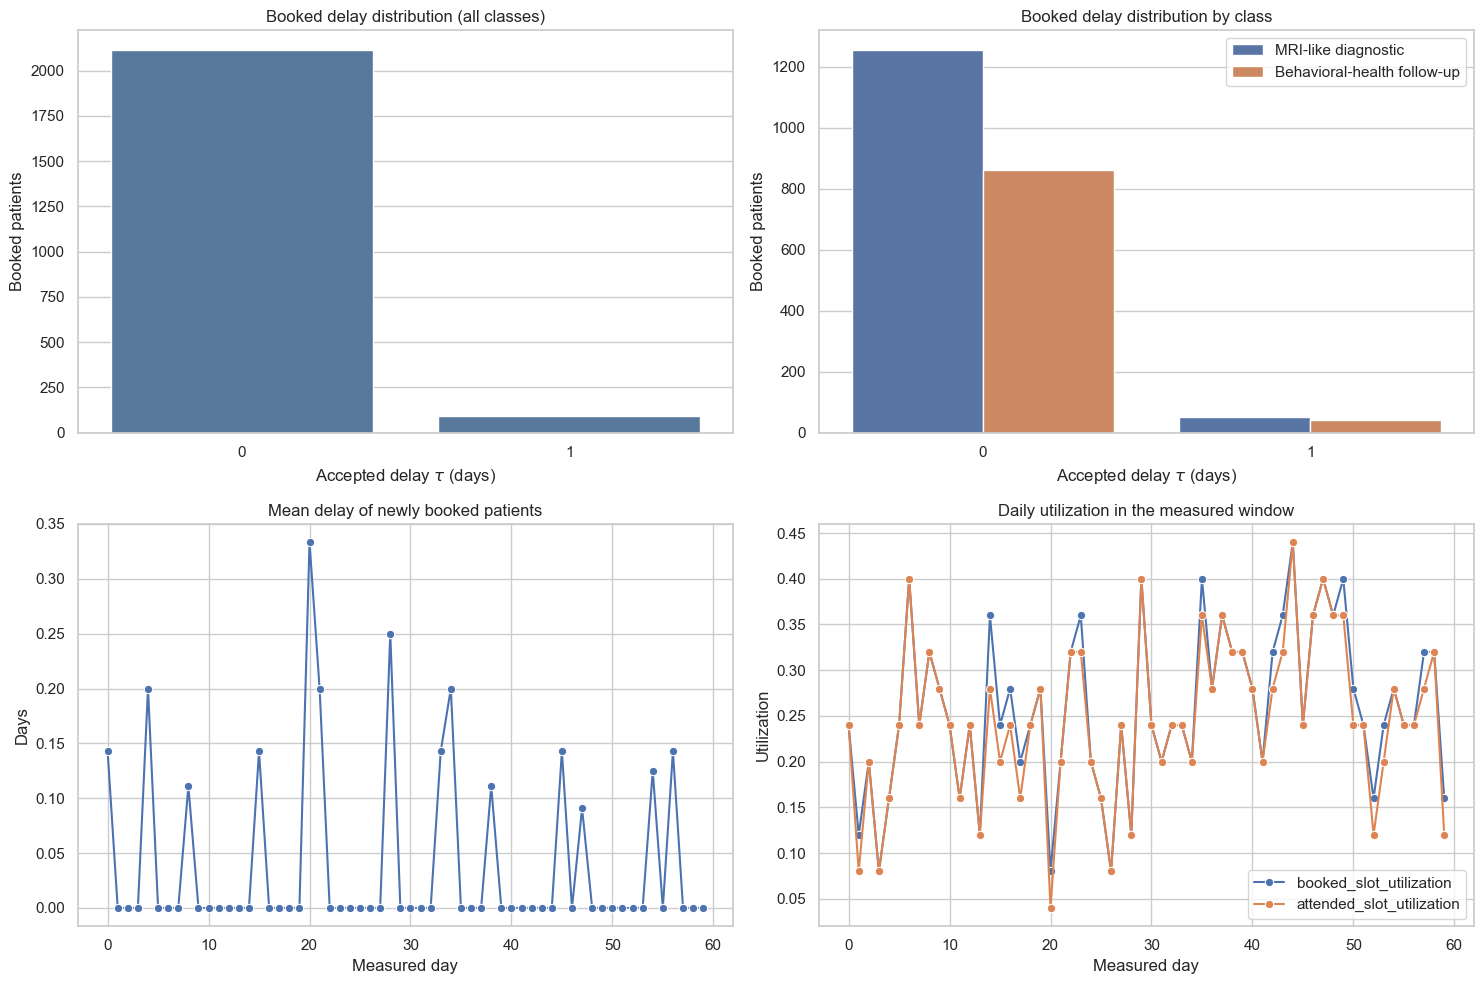

In [5]:
baseline_daily = baseline_result.daily_journal_aggregate.head(60).copy()
baseline_delays = delay_distribution_frame(baseline_result)
aggregate_delay_distribution = baseline_result.delay_distribution_aggregate.rename_axis("tau").reset_index(name="count")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=aggregate_delay_distribution, x="tau", y="count", color="#4C78A8", ax=axes[0, 0])
axes[0, 0].set_title("Booked delay distribution (all classes)")
axes[0, 0].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[0, 0].set_ylabel("Booked patients")

sns.barplot(data=baseline_delays, x="tau", y="count", hue="label", ax=axes[0, 1])
axes[0, 1].set_title("Booked delay distribution by class")
axes[0, 1].set_xlabel(r"Accepted delay $\tau$ (days)")
axes[0, 1].set_ylabel("Booked patients")
axes[0, 1].legend(title="")

sns.lineplot(
    data=baseline_daily,
    x="measured_day",
    y="mean_tau_booked_new_bookings",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Mean delay of newly booked patients")
axes[1, 0].set_xlabel("Measured day")
axes[1, 0].set_ylabel("Days")

journal_utilization = baseline_daily[
    ["measured_day", "booked_slot_utilization", "attended_slot_utilization"]
].melt(id_vars="measured_day", var_name="metric", value_name="value")
sns.lineplot(
    data=journal_utilization,
    x="measured_day",
    y="value",
    hue="metric",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Daily utilization in the measured window")
axes[1, 1].set_xlabel("Measured day")
axes[1, 1].set_ylabel("Utilization")
axes[1, 1].legend(title="")

plt.tight_layout()


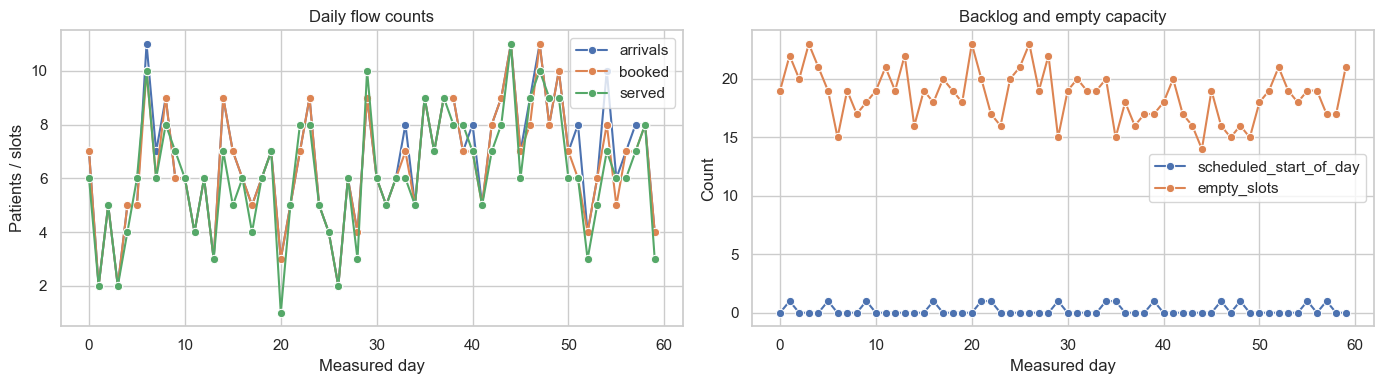

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

flow_df = baseline_daily[["measured_day", "arrivals", "booked", "served"]].melt(
    id_vars="measured_day",
    var_name="metric",
    value_name="count",
)
sns.lineplot(data=flow_df, x="measured_day", y="count", hue="metric", marker="o", ax=axes[0])
axes[0].set_title("Daily flow counts")
axes[0].set_xlabel("Measured day")
axes[0].set_ylabel("Patients / slots")
axes[0].legend(title="")

backlog_df = baseline_daily[["measured_day", "scheduled_start_of_day", "empty_slots"]].melt(
    id_vars="measured_day",
    var_name="metric",
    value_name="value",
)
sns.lineplot(data=backlog_df, x="measured_day", y="value", hue="metric", marker="o", ax=axes[1])
axes[1].set_title("Backlog and empty capacity")
axes[1].set_xlabel("Measured day")
axes[1].set_ylabel("Count")
axes[1].legend(title="")

plt.tight_layout()


## 4. Sensitivity to Total Arrival Rate `lambda`

This last block changes only the total arrival rate `\lambda`. The class mix `p` and the three behavior choices stay fixed.


In [7]:
TOTAL_LAMBDA_GRID = [0.16, 0.22, 0.28, 0.34, 0.40]
SWEEP_REPLICATIONS = 6

aggregate_sweep, class_sweep = run_fcfs_lambda_sweep(
    total_lambdas=TOTAL_LAMBDA_GRID,
    replications=SWEEP_REPLICATIONS,
)

display(aggregate_sweep.head())
display(class_sweep.head())


,replication,policy,arrivals,booked,balked,canceled,no_shows,served,mean_delay_booked,booked_within_access_target_per_arrival,booked_within_access_target_per_booked,served_per_booked,booked_slot_utilization,attended_slot_utilization,lambda_total
0,0,FCFSPolicy,1494.0,1445.0,49.0,2.0,92.0,1351.0,0.038062,0.967202,1.0,0.934948,0.158137,0.148055,0.16
1,1,FCFSPolicy,1506.0,1454.0,52.0,0.0,92.0,1362.0,0.042641,0.965471,1.0,0.936726,0.159342,0.149260,0.16
2,2,FCFSPolicy,1478.0,1434.0,44.0,2.0,85.0,1347.0,0.045328,0.970230,1.0,0.939331,0.156932,0.147616,0.16
3,3,FCFSPolicy,1437.0,1401.0,36.0,3.0,102.0,1296.0,0.048537,0.974948,1.0,0.925054,0.153205,0.142027,0.16
4,4,FCFSPolicy,1475.0,1416.0,59.0,1.0,87.0,1328.0,0.033898,0.960000,1.0,0.937853,0.155178,0.145644,0.16


,class_id,label,mean_delay_booked,booked_within_access_target_per_arrival,served_per_booked,lambda_total,replication
0,1,MRI-like diagnostic,0.038328,0.979522,0.993031,0.16,0
1,2,Behavioral-health follow-up,0.037671,0.949593,0.849315,0.16,0
2,1,MRI-like diagnostic,0.046988,0.985748,0.990361,0.16,1
3,2,Behavioral-health follow-up,0.036859,0.939759,0.865385,0.16,1
4,1,MRI-like diagnostic,0.053254,0.978009,0.991716,0.16,2


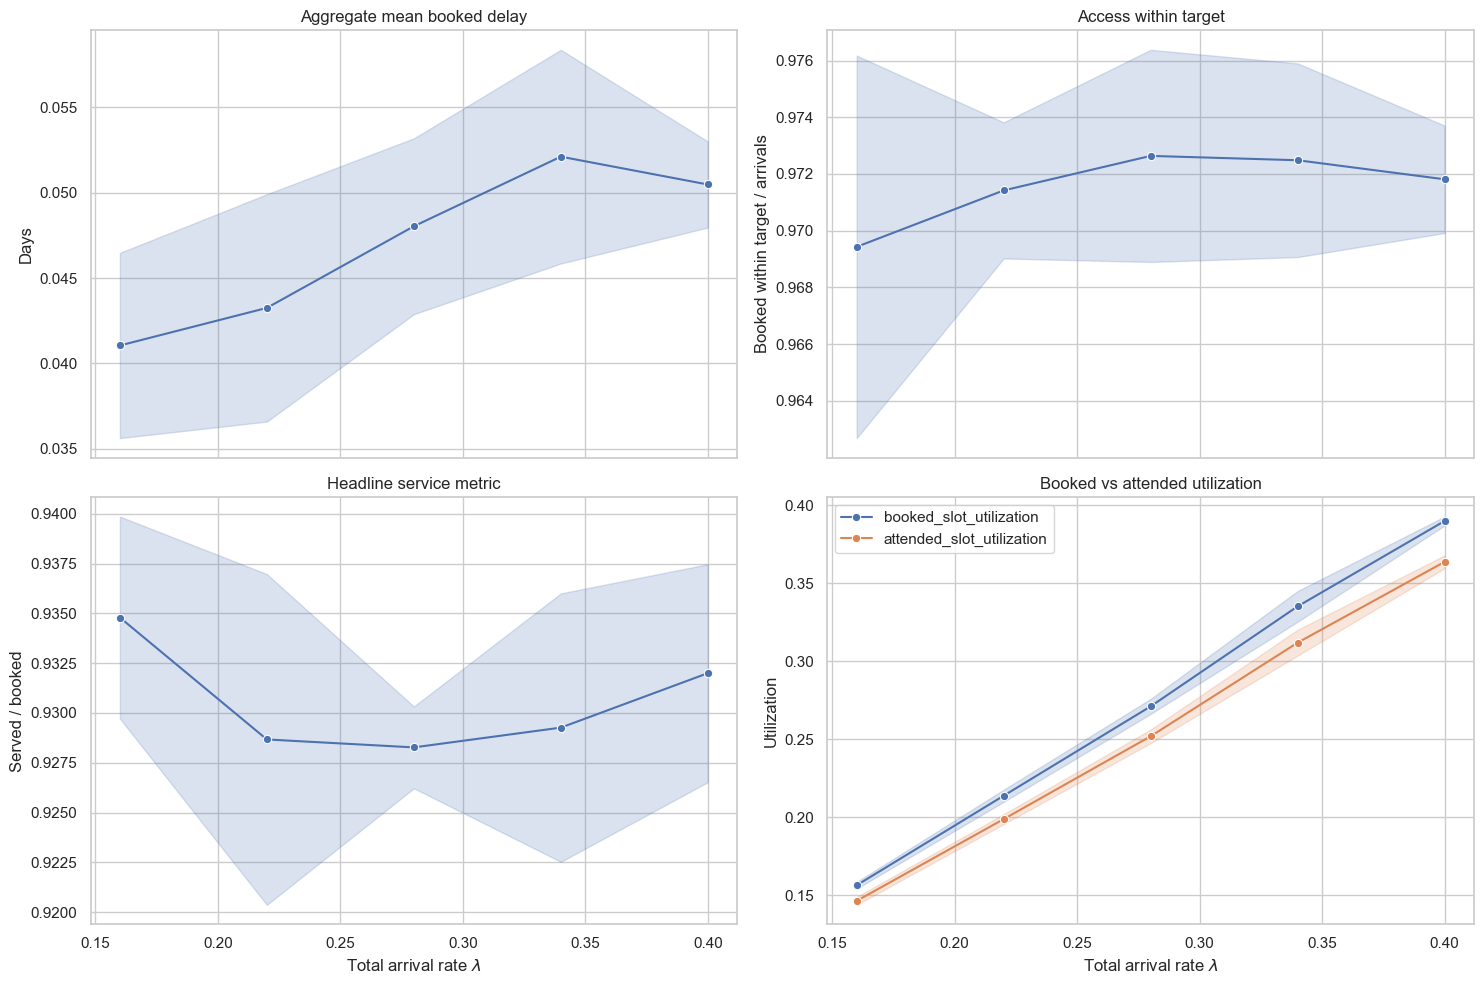

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

sns.lineplot(
    data=aggregate_sweep,
    x="lambda_total",
    y="mean_delay_booked",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Aggregate mean booked delay")
axes[0, 0].set_xlabel(r"Total arrival rate $\lambda$")
axes[0, 0].set_ylabel("Days")

sns.lineplot(
    data=aggregate_sweep,
    x="lambda_total",
    y="booked_within_access_target_per_arrival",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Access within target")
axes[0, 1].set_xlabel(r"Total arrival rate $\lambda$")
axes[0, 1].set_ylabel("Booked within target / arrivals")

sns.lineplot(
    data=aggregate_sweep,
    x="lambda_total",
    y="served_per_booked",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Headline service metric")
axes[1, 0].set_xlabel(r"Total arrival rate $\lambda$")
axes[1, 0].set_ylabel("Served / booked")

utilization_df = aggregate_sweep[["lambda_total", "booked_slot_utilization", "attended_slot_utilization"]].melt(
    id_vars="lambda_total",
    var_name="metric",
    value_name="value",
)
sns.lineplot(
    data=utilization_df,
    x="lambda_total",
    y="value",
    hue="metric",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Booked vs attended utilization")
axes[1, 1].set_xlabel(r"Total arrival rate $\lambda$")
axes[1, 1].set_ylabel("Utilization")
axes[1, 1].legend(title="")

plt.tight_layout()


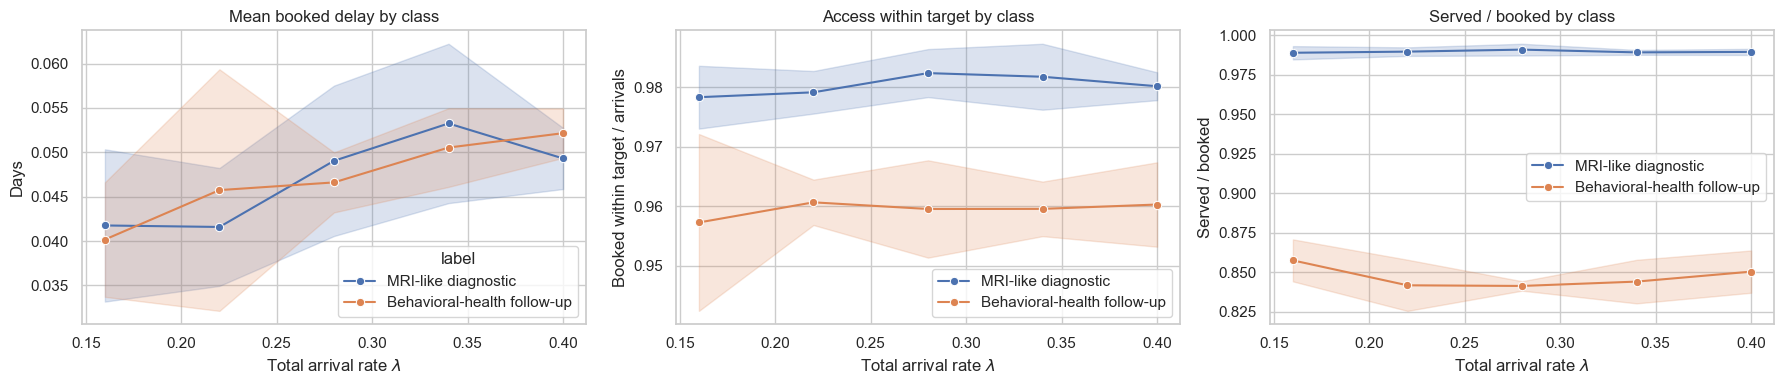

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

sns.lineplot(
    data=class_sweep,
    x="lambda_total",
    y="mean_delay_booked",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean booked delay by class")
axes[0].set_xlabel(r"Total arrival rate $\lambda$")
axes[0].set_ylabel("Days")

sns.lineplot(
    data=class_sweep,
    x="lambda_total",
    y="booked_within_access_target_per_arrival",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Access within target by class")
axes[1].set_xlabel(r"Total arrival rate $\lambda$")
axes[1].set_ylabel("Booked within target / arrivals")
axes[1].legend(title="")

sns.lineplot(
    data=class_sweep,
    x="lambda_total",
    y="served_per_booked",
    hue="label",
    estimator="mean",
    errorbar="sd",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Served / booked by class")
axes[2].set_xlabel(r"Total arrival rate $\lambda$")
axes[2].set_ylabel("Served / booked")
axes[2].legend(title="")

plt.tight_layout()
